**Défi quotidien : Créer un agent avec LangGraph et l'API Gemini**


👩‍🏫 👩🏿‍🏫 **Ce que vous apprendrez**

Comment créer une application avec état en utilisant LangGraph.

Comment intégrer l'API Gemini (via LangChain) dans votre application LangGraph.

Comment définir et manipuler un état à l'aide de TypedDict et des fonctions de nœud.

Comment simuler un comportement dynamique, augmenté par des outils (comme les menus et le tri) dans une boucle conversationnelle.

Comment modéliser les transitions conditionnelles, les boucles et l'interaction utilisateur à l'aide de LangGraph.

🛠️ **Ce que vous allez créer**

**BaristaBot** est un système de commande conversationnel pour les cafés . Ce bot permettra de :

Utilisez un langage naturel pour prendre les commandes de café/thé.

Proposez un menu en temps réel à l'aide d'un outil.
Confirmer et modifier les commandes.

Répéter la conversation jusqu'à ce qu'une commande soit passée.

Gérez les appels d'outils à l'aide du mécanisme ToolNode de LangGraph.

Cette application basée sur des graphes simulera un véritable assistant de café utilisant l'IA et la gestion d'état.

**Tâche**

Dans ce notebook, vous utiliserez LangGraph pour définir une application graphique à état, construite sur l'API Gemini.
Vous devrez utiliser les concepts suivants pour créer votre application :

* **LangGraph** : un framework pour créer des applications graphiques à état à l'aide de graphes.
* **TypedDict** : un type de données Python qui permet de définir des dictionnaires avec des types de données spécifiques.
* **ToolNode** : un type de nœud spécialisé dans la gestion des appels d'outils.
* **NodeState** : un type de données qui permet de définir l'état d'un nœud.

**Objectif**

Vous devrez créer une application graphique à état pour simuler un assistant de café. L'application doit permettre aux clients de commander des boissons en langage naturel, en utilisant un menu en temps réel et en gérant les appels d'outils pour les commandes.

**Instructions**

    . Importez les modules nécessaires pour créer votre application.
    . Créez un type de données `NodeState` pour définir l'état d'un nœud.
    . Créez un type de données `Menu` pour définir le menu en temps réel.


Vous développerez un système de commande de café simulé, appelé BaristaBot. Ce système offrira aux clients une interface de chat en boucle leur permettant de commander des boissons en langage naturel. Vous créerez des nœuds représentant le menu en direct du café et le système de commande interne.
BaristaBot est utilisé dans d'autres démonstrations de l'API Gemini. Si vous souhaitez explorer une implémentation plus minimaliste, consultez l'exemple d'appel de fonctions de BaristaBot, qui implémente un système similaire en utilisant uniquement le SDK Python de l'API Gemini et les appels de fonctions.

1. Commencez par installer et importer le SDK LangGraph et la prise en charge de LangChain pour l'API Gemini.

In [ ]:
%pip install -qU "langgraph==1.2.8" "langgraph-prebuilt==1.1.0" "langgraph-checkpoint==4.1.1" "langchain-google-genai==4.1.2" "google-genai==1.56.0" "typing_extensions" "python-dotenv"


2. Configurez votre clé API : La variable d’environnement GOOGLE_API_KEY permet de configurer automatiquement l’API sous-jacente. Cela fonctionne aussi bien avec le kit de développement logiciel (SDK) officiel Gemini Python qu’avec LangChain/LangGraph.

Pour exécuter la cellule suivante, votre clé API doit être stockée dans un secret Kaggle nommé GOOGLE_API_KEY.
Si vous n'en possédez pas encore, vous pouvez en obtenir une depuis AI Studio . Vous trouverez des instructions détaillées dans la documentation.
Pour rendre la clé disponible via les secrets Kaggle, sélectionnez « Secrets » dans le menu « Modules complémentaires » et suivez les instructions pour ajouter votre clé ou l'activer pour ce notebook.

In [ ]:
import os

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    # python-dotenv indisponible : on utilise les variables d'environnement existantes.
    pass

# Charge les variables depuis le fichier .env (NON versionne) si present ;
# sinon, utilise la variable d'environnement GEMINI_API_KEY (ou GOOGLE_API_KEY).
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
if not GEMINI_API_KEY:
    raise RuntimeError(
        "Cle API introuvable. Copiez .env.example en .env et renseignez GEMINI_API_KEY, "
        "ou installez python-dotenv et exportez la variable d'environnement GEMINI_API_KEY."
    )
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY
print("Cle API chargee depuis l'environnement (aucune cle en clair dans le notebook).")


✅ Clé API Gemini configurée avec succès!


Les applications LangGraph sont construites autour d'une structure de graphe. En tant que développeur, vous définissez un graphe d'application qui modélise les transitions d'état de votre application. Votre application définit un schéma d'état, et une instance de ce schéma est propagée à travers le graphe.

Chaque nœud du graphe représente une action ou une étape possible. Les nœuds modifient l'état d'une manière ou d'une autre grâce au code que vous définissez. Ces modifications peuvent résulter de l'invocation d'un LLM, de l'appel d'une API ou de l'exécution de toute logique définie par le nœud.

Chaque arête du graphe représente une transition entre deux états, définissant le flux du programme. Les transitions peuvent être fixes ; par exemple, pour un chatbot textuel dont la sortie est toujours affichée à l’utilisateur, la transition sera toujours de chatbot à utilisateur. Les transitions peuvent également être conditionnelles, permettant ainsi d’ajouter des embranchements (comme une instruction if-else) ou des boucles (comme des boucles for ou while).

3. **Définir les instructions principales** : L’état est un concept fondamental pour une application LangGraph. Un objet d’état est transmis entre chaque nœud et chaque transition de l’application. Ici, vous définissez un objet d’état, OrderState, qui contient l’historique des conversations, une commande structurée et un indicateur signalant si le client a terminé sa commande. Par souci de simplicité, la « structure » ​​de cette commande est une simple
liste de chaînes de caractères, mais elle peut être étendue à n’importe quelle structure de données Python.

En Python, l'objet d'état LangGraph est un dictionnaire Python. Vous pouvez définir un schéma pour ce dictionnaire en le déclarant comme un TypedDict.
Vous définissez également ici l'instruction système que le modèle Gemini utilisera. Vous pouvez y spécifier le ton et le style, ainsi que le scénario d'exécution du chatbot.

In [10]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class OrderState(TypedDict):
    """State representing the customer's order conversation."""

    # The chat conversation. This preserves the conversation history
    # between nodes. The `add_messages` annotation indicates to LangGraph
    # that state is updated by appending returned messages, not replacing
    # them.
    messages: Annotated[list, add_messages]

    # The customer's in-progress order.
    order: list[str]

    # Flag indicating that the order is placed and completed.
    finished: bool
# The system instruction defines how the chatbot is expected to behave and includes
# rules for when to call different functions, as well as rules for the conversation, such
# as tone and what is permitted for discussion.
BARISTABOT_SYSINT = (
    "system",  # 'system' indicates the message is a system instruction.
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items (and only about "
    "menu items - no off-topic discussion, but you can chat about the products and their history). "
    "The customer will place an order for 1 or more items from the menu, which you will structure "
    "and send to the ordering system after confirming the order with the human. "
    "\n\n"
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "To see the contents of the order so far, call get_order (this is shown to you, not the user) "
    "Always confirm_order with the user (double-check) before calling place_order. Calling confirm_order will "
    "display the order items to the user and returns their response to seeing the list. Their response may contain modifications. "
    "Always verify and respond with drink and modifier names from the MENU before adding them to the order. "
    "If you are unsure a drink or modifier matches those on the MENU, ask a question to clarify or redirect. "
    "You only have the modifiers listed on the menu. "
    "Once the customer has finished ordering items, Call confirm_order to ensure it is correct then make "
    "any necessary updates and then call place_order. Once place_order has returned, thank the user and "
    "say goodbye!",
)

# This is the message with which the system opens the conversation.
WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

4. **Définir un chatboot à tour unique**

Pour illustrer le fonctionnement de LangGraph, le programme suivant définit un nœud de chatbot qui exécutera un seul tour de conversation en utilisant les instructions fournies.

Chaque nœud du graphe agit sur l'objet état. L'état (un dictionnaire Python) est passé en paramètre au nœud (une fonction) et le nouvel état est renvoyé. On peut le reformuler en pseudo-code : état = nœud(état).

Remarque : Pour le nœud chatbot, l’état est mis à jour par l’ajout du nouveau message de conversation. L’annotation `add_messages` sur `OrderState.messages` indique que les messages sont ajoutés à la suite lorsqu’ils sont renvoyés par un nœud. En général, l’état est mis à jour par remplacement, mais cette annotation modifie le comportement des messages.

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI

# Try using different models. The `pro` models perform the best, especially
# with tool-calling. The `flash` models are super fast, and are a good choice
# if you need to use the higher free-tier quota.
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def chatbot(state: OrderState) -> OrderState:
    """The chatbot itself. A simple wrapper around the model's own chat interface."""
    message_history = [BARISTABOT_SYSINT] + state["messages"]
    return {"messages": [llm.invoke(message_history)]}


# Set up the initial graph based on our state definition.
graph_builder = StateGraph(OrderState)

# Add the chatbot function to the app graph as a node called "chatbot".
graph_builder.add_node("chatbot", chatbot)

# Define the chatbot node as the app entrypoint.
graph_builder.add_edge(START, "chatbot")

# Chatbot always goes to END for this single-turn demo.
graph_builder.add_edge("chatbot", END)

chat_graph = graph_builder.compile()


5. Visualisez le graphique que vous venez de définir.




## REPONSE

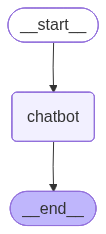

In [6]:
from IPython.display import Image

try:
    Image(chat_graph.get_graph().draw_mermaid_png())
except Exception as e:
    print(f"⚠️ Diagramme Mermaid indisponible (rendu hors-ligne ?): {e}")



6. Le graphe étant maintenant défini, vous pouvez l'exécuter. 

Il ne comporte qu'un seul nœud et une seule transition vers ce nœud. Il effectuera donc une transition de « début » à « chatbot », exécutera le nœud du chatbot, puis se terminera.

Pour exécuter le graphe, appelez la méthode `invoke` et transmettez un objet d'état initial. Dans ce cas, il démarre avec le message initial de l'utilisateur.

In [22]:
from pprint import pprint

user_msg = "Hi, I'd like to order a coffee"
state = chat_graph.invoke({"messages": [("user", user_msg)], "order": [], "finished": False})

# The state object contains lots of information. Uncomment the pprint lines to see it all.
# pprint(state)

# Note that the final state now has 2 messages. Our HumanMessage, and an additional AIMessage.
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 58.659489634s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

7. Vous pourriez exécuter cela dans une boucle Python, mais par souci de simplicité, il est préférable d'effectuer manuellement un dernier tour de conversation. Ce second appel reprend l'état du premier et y ajoute un autre message utilisateur afin de susciter une nouvelle réponse du chatbot.

In [ ]:
user_msg = "Can I get an iced latte with oat milk?"

state["messages"].append(("user", user_msg))
state = chat_graph.invoke(state)

# pprint(state)
for msg in state["messages"]:
    print(f"{type(msg).__name__}: {msg.content}")


NameError: name 'state' is not defined

8. Ajouter un nœud humain : Au lieu d'exécuter à plusieurs reprises le « graphe » dans une boucle Python, vous pouvez utiliser LangGraph pour boucler entre les nœuds.

Le nœud humain affichera le dernier message du LLM à l'utilisateur, puis l'invitera à saisir sa prochaine information. Ici, cela se fait à l'aide des fonctions d'affichage et de saisie standard de Python, mais dans un contexte de café réel, il serait possible d'afficher la conversation sur un écran ou de diffuser du son, et de recevoir les entrées via un microphone ou un clavier virtuel.

La fonction du nœud de chatbot a également été mise à jour afin d'inclure le message de bienvenue pour démarrer la conversation. Complétez le code suivant :

In [ ]:
from langchain_core.messages.ai import AIMessage


def human_node(state: OrderState) -> OrderState:
    """Display the last model message to the user, and receive the user's input."""
    msgs = state.get("messages", [])
    if not msgs:
        return state | {"messages": [("user", "")]}
    
    last_msg = msgs[-1]
    
    # Afficher le dernier message du modèle
    if hasattr(last_msg, "content"):
        print(f"\nAssistant: {last_msg.content}")
    
    try:
        user_input = input("You: ").strip()
    except EOFError:
        # Si pas d'entrée (environnement non interactif)
        user_input = "q"

    # Si l'utilisateur veut quitter
    finished = user_input.lower() in {"q", "quit", "exit", "goodbye", "bye"}

    return state | {"messages": [("user", user_input)], "finished": finished}


def chatbot_with_welcome_msg(state: OrderState) -> OrderState:
    """The chatbot itself. A wrapper around the model's own chat interface."""
    
    try:
        if state.get("messages"):
            # If there are messages, continue the conversation with the Gemini model.
            new_output = llm.invoke([BARISTABOT_SYSINT] + state["messages"])
        else:
            # If there are no messages, start with the welcome message.
            new_output = AIMessage(content=WELCOME_MSG)
    except Exception as e:
        print(f"⚠️ Erreur API: {type(e).__name__}")
        new_output = AIMessage(content="I apologize, but I'm experiencing technical difficulties. Please try again.")

    return state | {"messages": [new_output]}


# Start building a new graph.
graph_builder = StateGraph(OrderState)

# Add the chatbot and human nodes to the app graph.
graph_builder.add_node("chatbot", chatbot_with_welcome_msg)
graph_builder.add_node("human", human_node)

# Start with the chatbot again.
graph_builder.add_edge(START, "chatbot")

# The chatbot will always go to human next.
graph_builder.add_edge("chatbot", "human")

print("✅ Nœuds chatbot et human créés")


9. Avant d'exécuter ce code, veuillez noter que si vous ajoutez une arête reliant l'utilisateur au chatbot, le graphe bouclera indéfiniment, faute de condition de sortie. Pour interrompre cette boucle, vous pouvez ajouter une vérification de la saisie de l'utilisateur, par exemple « q » ou « quit », afin de sortir de la boucle.

Dans LangGraph, cela se fait grâce à une arête conditionnelle. Le principe est similaire à une transition de graphe classique, à ceci près qu'une fonction personnalisée est appelée pour déterminer l'arête à parcourir.

Les fonctions de transition conditionnelles prennent l'état en entrée et renvoient une chaîne de caractères représentant le nom du nœud vers lequel elles effectueront la transition. Complétez ce code :

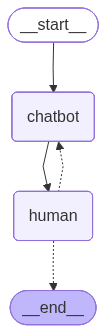

In [ ]:
from typing import Literal


def maybe_exit_human_node(state: OrderState) -> Literal["chatbot", "__end__"]:
    """Route to the chatbot, unless it looks like the user is exiting."""
    if state.get("finished", False):
        return END
    else:
        return "chatbot"


# Add conditional edges for the human node
graph_builder.add_conditional_edges("human", maybe_exit_human_node)

# Compile the graph for testing
chat_with_human_graph = graph_builder.compile()

print("✅ Graphe avec boucle human-chatbot créé")

from IPython.display import Image
try:
    Image(chat_with_human_graph.get_graph().draw_mermaid_png())
except Exception as e:
    print(f"⚠️ Impossible de générer le diagramme: {e}")


10. Ajouter un menu dynamique. BaristaBot ignore actuellement la disponibilité des produits au café et affiche donc un menu par défaut. Une solution consiste à intégrer directement le menu dans l'interface système. Cette méthode fonctionne, mais pour simuler un système où le menu est plus dynamique et s'adapte aux variations de stock, il est préférable d'utiliser un outil personnalisé.

Ce système utilise deux types d'outils : des outils sans état, qui s'exécutent automatiquement, et des outils avec état, qui modifient l'ordre du menu. L'outil « obtenir le menu actuel » est sans état, car il ne modifie pas l'ordre du menu en temps réel et peut donc être appelé automatiquement.

Dans une application LangGraph, vous pouvez annoter les fonctions Python en tant qu'outils en appliquant l'annotation @tools.

In [ ]:
from langchain_core.tools import tool


@tool
def get_menu() -> str:
    """Provide the latest up-to-date menu."""
    return """
MENU:

Coffee Drinks:
- Espresso
- Americano
- Cold Brew

Coffee Drinks with Milk:
- Latte
- Cappuccino
- Cortado
- Macchiato
- Mocha
- Flat White

Tea Drinks:
- English Breakfast Tea
- Green Tea
- Earl Grey

Tea Drinks with Milk:
- Chai Latte
- Matcha Latte
- London Fog

Other Drinks:
- Steamer
- Hot Chocolate

MODIFIERS:
- Milk options: Whole, 2%, Oat, Almond, 2% Lactose Free (default: whole)
- Espresso shots: Single, Double, Triple, Quadruple (default: Double)
- Caffeine: Decaf, Regular (default: Regular)
- Hot/Iced: Hot, Iced (default: Hot)
- Sweeteners: vanilla, hazelnut, caramel, chocolate, sugar-free vanilla
- Special requests: extra hot, one pump, half caff, extra foam, etc.

NOTES:
- "dirty" = add espresso shot (e.g., "Dirty Chai Latte")
- Soy milk is OUT OF STOCK today
- Regular milk = whole milk
"""


Ajoutez maintenant le nouvel outil au graphe. L'outil `get_menu` est intégré à un nœud `ToolNode` qui gère son appel et la transmission de la réponse sous forme de message à travers le graphe. 

Les outils sont également liés à l'objet `llm` afin que le modèle sous-jacent les reconnaisse. Puisque vous utilisez désormais un objet `llm` différent, vous devez mettre à jour le nœud du chatbot pour qu'il prenne en compte ces outils.

11. Gestion des commandes. Pour constituer une commande pendant la conversation, vous devrez mettre à jour l'état afin de suivre sa progression et fournir des outils simples pour effectuer ces mises à jour. Ces outils doivent être explicites, car le modèle ne doit pas avoir d'accès direct à l'état interne de l'application, sous peine de risquer une manipulation arbitraire.

Les outils de tri seront ajoutés sous forme de stubs dans un nœud séparé afin que vous puissiez modifier directement leur état. L'annotation `@tool` reste un moyen pratique de définir leur schéma ; les outils de tri ci-dessous sont donc implémentés comme des fonctions Python vides.
Complétez ce code :

In [ ]:
from collections.abc import Iterable
from random import randint
from langchain_core.messages.tool import ToolMessage

# --- Outils de commande (stubs pour démonstration) ---
@tool
def add_to_order(drink: str, modifiers: Iterable[str]) -> str:
    """Ajoute une boisson avec ses modificateurs à la commande."""
    return f"Added {drink} to order"

@tool
def confirm_order() -> str:
    """Demande confirmation de la commande à l'utilisateur."""
    return "Please confirm your order"

@tool
def get_order() -> str:
    """Retourne la commande en cours (1 item par ligne)."""
    return "Current order retrieved"

@tool
def clear_order():
    """Efface toute la commande."""
    return "Order cleared"

@tool
def place_order() -> str:
    """Envoie la commande au barista. Retourne le temps d'attente estimé (minutes)."""
    wait_time = randint(3, 8)
    return f"Order placed! Estimated wait: {wait_time} minutes"

# --- Noeud de gestion des commandes ---
def order_node(state: OrderState) -> OrderState:
    """Gère les appels d'outils liés à la commande."""
    tool_msg = state["messages"][-1]
    order = list(state["order"])
    outbound_msgs = []
    order_placed = False

    # Vérifie que tool_msg a des tool_calls
    if not hasattr(tool_msg, "tool_calls") or not tool_msg.tool_calls:
        return {"messages": [], "order": order, "finished": False}

    for tool_call in tool_msg.tool_calls:
        try:
            if tool_call["name"] == "add_to_order":
                modifiers = tool_call["args"].get("modifiers", [])
                if isinstance(modifiers, str):
                    modifiers = [modifiers]
                modifier_str = ", ".join(modifiers) if modifiers else "no modifiers"
                order.append(f'{tool_call["args"]["drink"]} ({modifier_str})')
                response = f"✅ Added to order. Total items: {len(order)}"

            elif tool_call["name"] == "confirm_order":
                print("\n--- Votre commande ---")
                if not order:
                    print("  (aucune boisson)")
                    response = "No items in order"
                else:
                    for i, drink in enumerate(order, 1):
                        print(f"  {i}. {drink}")
                    response = "Order confirmed"

            elif tool_call["name"] == "get_order":
                response = "\n".join(order) if order else "(empty order)"

            elif tool_call["name"] == "clear_order":
                order.clear()
                response = "✅ Order cleared"

            elif tool_call["name"] == "place_order":
                if not order:
                    response = "❌ Cannot place empty order"
                else:
                    wait_time = randint(3, 8)
                    print(f"\n✅ Commande envoyée ! Temps d'attente: {wait_time} min")
                    for drink in order:
                        print(f"   - {drink}")
                    order_placed = True
                    response = f"Order placed! Wait time: {wait_time} minutes"

            else:
                response = f"❌ Unknown tool: {tool_call['name']}"

        except Exception as e:
            response = f"Error executing {tool_call['name']}: {str(e)}"

        outbound_msgs.append(
            ToolMessage(
                content=str(response),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outbound_msgs, "order": order, "finished": order_placed}


12. Définissez maintenant le graphe. Le LLM doit également connaître les outils pour pouvoir les utiliser. Configurez ici deux ensembles d'outils correspondant aux nœuds sous lesquels ils opèrent : outils automatisés et outils de commande.

In [ ]:
from langgraph.prebuilt import ToolNode
from typing import Literal

# --- Definition des outils ---
auto_tools = [get_menu]
order_tools = [add_to_order, confirm_order, get_order, clear_order, place_order]

# Creer le noeud d'outils pour les outils automatiques
tool_node = ToolNode(auto_tools)

# Lier TOUS les outils au LLM
llm_with_tools = llm.bind_tools(auto_tools + order_tools)

# --- Fonction de routage unifiee ---
def maybe_route_to_tools(state: OrderState) -> str:
    """Route vers : tools, ordering, human, ou END."""
    if state.get("finished", False):
        return END
    
    if not (msgs := state.get("messages", [])):
        raise ValueError(f"Aucun message trouvé : {state}")
    
    msg = msgs[-1]
    
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tool_call in msg.tool_calls:
            if tool_call["name"] in tool_node.tools_by_name:
                return "tools"
        return "ordering"
    else:
        return "human"

# --- Chatbot avec outils ---
def chatbot_with_tools(state: OrderState) -> OrderState:
    """Chatbot avec prise en charge des outils."""
    defaults = {"order": [], "finished": False}
    
    if state["messages"]:
        new_output = llm_with_tools.invoke([BARISTABOT_SYSINT] + state["messages"])
    else:
        new_output = AIMessage(content=WELCOME_MSG)
    
    return defaults | state | {"messages": [new_output]}

# --- Construction du graphe final ---
graph_builder = StateGraph(OrderState)

# Ajouter les noeuds
graph_builder.add_node("chatbot", chatbot_with_tools)
graph_builder.add_node("human", human_node)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("ordering", order_node)

# Definir les aretes
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", maybe_route_to_tools)
graph_builder.add_conditional_edges("human", maybe_exit_human_node)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("ordering", "chatbot")

# Compiler le graphe
graph_with_order_tools = graph_builder.compile()

from IPython.display import Image
try:
    Image(graph_with_order_tools.get_graph().draw_mermaid_png())
except Exception as e:
    print(f"⚠️ Diagramme Mermaid indisponible (rendu hors-ligne ?): {e}")


ImportError: cannot import name 'ExecutionInfo' from 'langgraph.runtime' (c:\Users\DELL\Desktop\TTA_Donald_KOUASSI\.venv\Lib\site-packages\langgraph\runtime.py)

Exécutez maintenant le graphique complet du système de commande.

In [ ]:
try:
    # Configuration pour permettre des conversations longues
    config = {"recursion_limit": 100}

    # Démarrer la conversation
    print(">> BaristaBot est prêt ! Tapez 'q' pour quitter.\n")
    state = graph_with_order_tools.invoke({"messages": []}, config)

    # Afficher le résultat final
    print("\n--- État final ---")
    print(f"Commande terminée : {state['finished']}")
    print(f"Boissons commandées : {state['order']}")
except KeyboardInterrupt:
    print("\n⏹️ Conversation arrêtée par l'utilisateur")
except Exception as e:
    print(f"\n❌ Erreur: {type(e).__name__}")
    print(f"📌 Vérifiez que:")
    print(f"   1. Votre clé API est valide")
    print(f"   2. Le quota n'est pas épuisé")
    print(f"   3. Toutes les cellules précédentes ont été exécutées sans erreur")
    print(f"\n💡 Pour déboguer: Vérifiez la cellule 2 (Configuration API)")


>> BaristaBot est prêt ! Tapez 'q' pour quitter.



NameError: name 'graph_with_order_tools' is not defined

## 📋 Instructions pour utiliser BaristaBot

### ✅ Avant de commencer:
1. **Obtenez une clé API gratuite**: https://aistudio.google.com/app/apikey
2. **Configurez la clé** via le fichier `.env` (copiez `.env.example` -> `.env`)
3. **Exécutez les cellules** dans l'ordre

### 🚀 Déploiement avec Google Gemini + LangGraph:
BaristaBot utilise actuellement **Google Gemini + LangGraph**, 

### 📊 Structure du graphe:
```
START 
  ↓
chatbot (Gemini LLM)
  ↓ (routes based on tool calls)
├─ tools (get_menu) → chatbot
├─ ordering (place_order, etc.) → chatbot
└─ human (user input) → chatbot or END

END
```

### 🔧 Dépannage:
- **Quota épuisé**: Attendez demain ou créez un nouveau projet Gemini
- **Clé invalide**: Vérifiez la clé dans https://aistudio.google.com
- **Erreur import**: Réexécutez cellule 1 (pip install)
